# 1.7.1 Camera Calibration

In [23]:
import numpy as np
import cv2
import glob
from matplotlib import pyplot as plt

In [24]:
# termination criteria
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

In [25]:
# prepare object points, like (0,0,0), (1,0,0), (2,0,0) ....,(6,5,0)
objp = np.zeros((9*6,3), np.float32)
objp[:,:2] = np.mgrid[0:9,0:6].T.reshape(-1,2)

In [26]:
# Arrays to store object points and image points from all the images.
objpoints = [] # 3d point in real world space
imgpoints = [] # 2d points in image plane.
images = glob.glob('.\iphone2\*.jpg') #('.\Image\*.png')

In [27]:
len(images)

15

In [29]:
for fname in images:
    img = cv2.imread(fname)
    gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    # Find the chess board corners
    ret, corners = cv2.findChessboardCorners(gray, (9,6),None) #(7,6)
    # If found, add object points, image points (after refining them)
    if ret == True:
        objpoints.append(objp)
        corners2 = cv2.cornerSubPix(gray,corners,(11,11),(-1,-1),criteria)
        imgpoints.append(corners2)
        # Draw and display the corners
        img = cv2.drawChessboardCorners(img, (9,6), corners2,ret)
        cv2.imshow('img',img)
        cv2.waitKey(0)
cv2.destroyAllWindows()

In [30]:
print(objpoints)

[array([[0., 0., 0.],
       [1., 0., 0.],
       [2., 0., 0.],
       [3., 0., 0.],
       [4., 0., 0.],
       [5., 0., 0.],
       [6., 0., 0.],
       [7., 0., 0.],
       [8., 0., 0.],
       [0., 1., 0.],
       [1., 1., 0.],
       [2., 1., 0.],
       [3., 1., 0.],
       [4., 1., 0.],
       [5., 1., 0.],
       [6., 1., 0.],
       [7., 1., 0.],
       [8., 1., 0.],
       [0., 2., 0.],
       [1., 2., 0.],
       [2., 2., 0.],
       [3., 2., 0.],
       [4., 2., 0.],
       [5., 2., 0.],
       [6., 2., 0.],
       [7., 2., 0.],
       [8., 2., 0.],
       [0., 3., 0.],
       [1., 3., 0.],
       [2., 3., 0.],
       [3., 3., 0.],
       [4., 3., 0.],
       [5., 3., 0.],
       [6., 3., 0.],
       [7., 3., 0.],
       [8., 3., 0.],
       [0., 4., 0.],
       [1., 4., 0.],
       [2., 4., 0.],
       [3., 4., 0.],
       [4., 4., 0.],
       [5., 4., 0.],
       [6., 4., 0.],
       [7., 4., 0.],
       [8., 4., 0.],
       [0., 5., 0.],
       [1., 5., 0.],
       [2., 

In [31]:
print(imgpoints)

[array([[[690.7605 , 467.47897]],

       [[644.1967 , 466.90402]],

       [[598.45264, 466.4645 ]],

       [[552.5948 , 465.84924]],

       [[507.91107, 465.44467]],

       [[463.38348, 465.1155 ]],

       [[418.5802 , 464.7617 ]],

       [[374.3085 , 464.68097]],

       [[329.6823 , 464.60138]],

       [[688.04877, 423.60507]],

       [[642.3116 , 423.40332]],

       [[597.51715, 423.1789 ]],

       [[552.7594 , 422.5725 ]],

       [[509.09998, 422.39792]],

       [[465.44513, 422.22446]],

       [[421.66122, 422.10718]],

       [[378.2791 , 421.90152]],

       [[334.60565, 421.84323]],

       [[685.301  , 381.87045]],

       [[640.53534, 381.81296]],

       [[596.7001 , 381.7725 ]],

       [[553.0196 , 381.54822]],

       [[510.19055, 381.30447]],

       [[467.36374, 381.31058]],

       [[424.4899 , 381.40942]],

       [[382.0321 , 381.43585]],

       [[339.29926, 381.37085]],

       [[682.7736 , 341.6021 ]],

       [[639.0323 , 341.80438]],

       [[596.

In [11]:
cv2.imshow('img',img)

## Calibration

In [32]:
ret, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints, gray.shape[::-1],None,None)

In [34]:
mtx

array([[726.19356462,   0.        , 511.1127435 ],
       [  0.        , 723.8748014 , 396.64701166],
       [  0.        ,   0.        ,   1.        ]])

In [35]:
dist

array([[ 5.27923697e-02,  5.92525500e-01,  5.56731673e-03,
        -1.46388564e-03, -3.80008066e+00]])

In [36]:
print(rvecs)

(array([[-0.09234928],
       [-0.52829069],
       [-3.08187715]]), array([[-0.16550055],
       [ 0.57600911],
       [ 2.58683424]]), array([[-0.3855838 ],
       [ 0.37948771],
       [ 1.56857122]]), array([[-0.36277172],
       [ 0.17247319],
       [ 0.87368237]]), array([[-0.39747064],
       [ 0.20160848],
       [ 0.24130788]]), array([[-0.2751154 ],
       [-0.54708166],
       [-1.83944481]]), array([[-0.50171409],
       [-0.26054066],
       [-1.51818348]]), array([[-0.45271546],
       [ 0.11114487],
       [-1.58918572]]), array([[ 1.11317829e-03],
       [ 1.71637117e-01],
       [-2.29938076e+00]]), array([[ 0.14517936],
       [ 0.05698483],
       [-1.82903242]]), array([[-0.33054718],
       [-0.43276339],
       [-2.45124665]]), array([[-0.45601612],
       [-0.12287543],
       [-2.45164174]]), array([[ 0.17476977],
       [-0.63278807],
       [-2.82015952]]), array([[-0.025408  ],
       [-0.54220573],
       [-3.07281933]]), array([[-0.1213315 ],
       [ 0.33

In [37]:
tvecs

(array([[ 3.92143789],
        [ 1.54440441],
        [15.92882417]]),
 array([[ 4.67805707],
        [-1.00229581],
        [20.13310808]]),
 array([[ 2.73089896],
        [-5.96085937],
        [24.35988583]]),
 array([[-2.05360167],
        [-6.60672304],
        [19.80909526]]),
 array([[-4.98749531],
        [-4.98725775],
        [22.58221168]]),
 array([[-3.18970911],
        [ 2.15050604],
        [15.54715317]]),
 array([[-4.48322447],
        [ 2.32760683],
        [15.22586379]]),
 array([[-2.87230347],
        [ 3.48558168],
        [16.0919528 ]]),
 array([[ 0.76080942],
        [ 5.54336808],
        [18.73826034]]),
 array([[-1.847525  ],
        [ 5.92322471],
        [18.82249977]]),
 array([[ 1.29224772],
        [ 3.57410977],
        [17.08217455]]),
 array([[-0.16673852],
        [ 5.49984376],
        [18.44763045]]),
 array([[ 3.41116004],
        [ 3.82925466],
        [19.00296506]]),
 array([[ 3.17247569],
        [ 2.05655238],
        [20.3407055 ]]),
 array

## Undistortion

In [47]:
img = cv2.imread('./iphone2/IMG_7298.jpg')
h, w = img.shape[:2]
newcameramtx, roi=cv2.getOptimalNewCameraMatrix(mtx,dist,(w,h),1,(w,h))

## 1. Using cv2.undistort()

In [48]:
# undistort
dst = cv2.undistort(img, mtx, dist, None, newcameramtx)
# crop the image
x,y,w,h = roi
dst = dst[y:y+h, x:x+w]
cv2.imwrite('calibresult.png',dst)

True

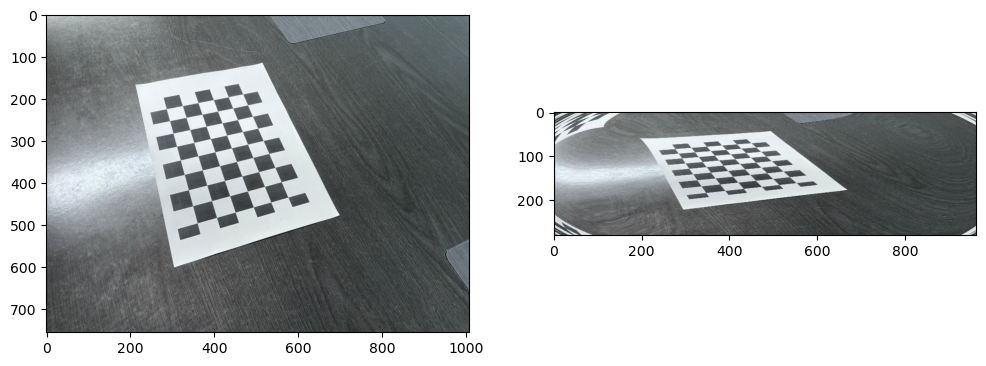

In [49]:
plt.figure(figsize=(12,8))
plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(dst)
plt.show()

In [46]:
print("roi :", roi)
print(dst.shape)

roi : (44, 473, 963, 280)
(0, 919, 3)


## 2. Using remapping

In [52]:
# undistort
mapx,mapy = cv2.initUndistortRectifyMap(mtx,dist,None,newcameramtx,(w,h),cv2.CV_32FC1)
dst = cv2.remap(img,mapx,mapy,cv2.INTER_LINEAR)
#dst = cv2.undistort(img, mtx, dist, None, newcameramtx)
# crop the image
x,y,roi_w,roi_h = roi
dst = dst[y:y+roi_h, x:x+roi_w]
cv2.imwrite('calibresult.png',dst)

error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\imgcodecs\src\loadsave.cpp:1193: error: (-215:Assertion failed) !_img.empty() in function 'cv::imwrite'


In [53]:
h, w = img.shape[:2]

mapx, mapy = cv2.initUndistortRectifyMap(
    mtx, dist, None, newcameramtx, (w, h), cv2.CV_32FC1
)

dst = cv2.remap(img, mapx, mapy, cv2.INTER_LINEAR)

print("before crop:", dst.shape)
print("roi:", roi)

x, y, roi_w, roi_h = roi

# 🔥 안전 crop
h_img, w_img = dst.shape[:2]

x = max(0, x)
y = max(0, y)
roi_w = min(roi_w, w_img - x)
roi_h = min(roi_h, h_img - y)

if roi_w > 0 and roi_h > 0:
    dst = dst[y:y+roi_h, x:x+roi_w]
else:
    print("ROI invalid → skip crop")

print("after crop:", dst.shape)

cv2.imwrite("calibresult.png", dst)

before crop: (756, 1008, 3)
roi: (44, 473, 963, 280)
after crop: (280, 963, 3)


True

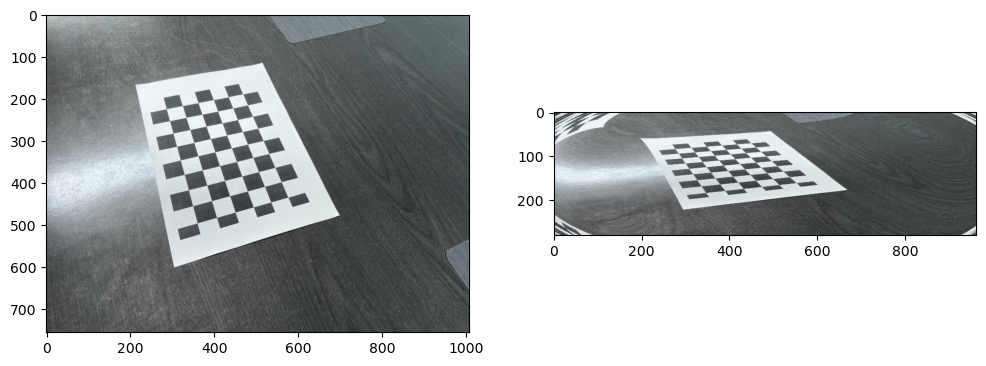

In [54]:
plt.figure(figsize=(12,8))
plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(dst)
plt.show()

## Re-projection Error

In [55]:
tot_error = 0
for i in range(len(objpoints)):
    imgpoints2, _ = cv2.projectPoints(objpoints[i], rvecs[i], tvecs[i], mtx, dist)
    error = cv2.norm(imgpoints[i],imgpoints2, cv2.NORM_L2)/len(imgpoints2)
    tot_error += error
print("mean error: ", tot_error/len(objpoints))

mean error:  0.02962940394780702
